In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from functions import (
    emd_modes, vmd_modes, dominant_period, 
    mean_zero_crossing_distance, acf_decay_lag
)


returns = pd.read_parquet("../../data/02_clean/returns_2019.parquet")
returns = returns.loc[:, ~returns.isna().all()]

fast_emd, medium_emd, slow_emd = emd_modes(data=returns)
modes_vmd = vmd_modes(data=returns)

100%|██████████| 754/754 [00:07<00:00, 102.57it/s]


In [2]:
rows = []

for col in fast_emd.columns:
    rows.append({
        "asset": col,

        # ===== EMD =====
        "fast_emd_period": dominant_period(fast_emd[col]),
        "fast_emd_zc": mean_zero_crossing_distance(fast_emd[col]),
        "fast_emd_acf": acf_decay_lag(fast_emd[col]),

        "medium_emd_period": dominant_period(medium_emd[col]),
        "medium_emd_zc": mean_zero_crossing_distance(medium_emd[col]),
        "medium_emd_acf": acf_decay_lag(medium_emd[col]),

        "slow_emd_period": dominant_period(slow_emd[col]),
        "slow_emd_zc": mean_zero_crossing_distance(slow_emd[col]),
        "slow_emd_acf": acf_decay_lag(slow_emd[col]),

        # ===== VMD (K=3) =====
        "fast_vmd_period": dominant_period(modes_vmd[2][col]),
        "fast_vmd_zc": mean_zero_crossing_distance(modes_vmd[2][col]),
        "fast_vmd_acf": acf_decay_lag(modes_vmd[2][col]),

        "medium_vmd_period": dominant_period(modes_vmd[1][col]),
        "medium_vmd_zc": mean_zero_crossing_distance(modes_vmd[1][col]),
        "medium_vmd_acf": acf_decay_lag(modes_vmd[1][col]),

        "slow_vmd_period": dominant_period(modes_vmd[0][col]),
        "slow_vmd_zc": mean_zero_crossing_distance(modes_vmd[0][col]),
        "slow_vmd_acf": acf_decay_lag(modes_vmd[0][col]),
    })

results = pd.DataFrame(rows)

In [3]:
summary = results.drop(columns=["asset"]).median().to_frame(name="median")
summary = summary.reset_index().rename(columns={"index": "metric"})
summary[summary["metric"].str.contains("period")]

,metric,median
0,fast_emd_period,3.217949
3,medium_emd_period,50.200000
6,slow_emd_period,251.000000
9,fast_vmd_period,3.012048
12,medium_vmd_period,5.952381
15,slow_vmd_period,30.000000


## Comparison Between EMD and VMD with Three Modes

We compare the time-scale separation produced by **Empirical Mode Decomposition (EMD)** and **Variational Mode Decomposition (VMD)** when the latter is restricted to three modes (\(K = 3\)). For each asset, dominant periods are estimated using spectral analysis, and the **cross-sectional medians** of these periods are reported.

### Dominant Periods

**Empirical Mode Decomposition (EMD):**

- **Fast EMD:** 3.22 days  
- **Medium EMD:** 50.20 days  
- **Slow EMD:** 251.00 days  

**Variational Mode Decomposition (VMD, \(K = 3\)):**

- **Fast VMD:** 3.01 days  
- **Medium VMD:** 5.95 days  
- **Slow VMD:** 30.00 days  

### Short-Term Dynamics

The fast components identified by both methods are remarkably consistent, with dominant periods close to three trading days. This agreement indicates that short-term market fluctuations are robustly captured regardless of the decomposition technique and are largely independent of modeling assumptions.

### Medium- and Long-Term Dynamics

Substantial differences emerge at longer horizons. EMD identifies a medium-term component with a characteristic period of approximately 50 days and a slow component corresponding to an annual cycle of roughly 250 days. In contrast, VMD with \(K = 3\) allocates its medium and slow modes to significantly shorter horizons, centered around weekly (≈6 days) and monthly (≈30 days) dynamics.

### Methodological Interpretation

These discrepancies arise from the fundamental methodological distinction between the two approaches. EMD is fully data-adaptive and extracts oscillatory components until no additional local extrema remain, allowing it to isolate low-frequency, regime-like behavior in financial returns. VMD, by contrast, solves a constrained variational problem in which the signal is decomposed into a fixed number of band-limited modes. When \(K\) is small, this constraint forces the available spectral energy to be distributed across relatively narrow and higher-frequency bands, preventing the emergence of very long-horizon components.

### Implications

Consequently, VMD with \(K = 3\) should be interpreted as a short-to-medium-term decomposition, well suited for identifying weekly and monthly dynamics but not for capturing long-run market regimes. EMD, by contrast, naturally separates short-term noise from medium-term cycles and long-term trends without imposing an *a priori* limit on the number or bandwidth of modes.

### Summary

In summary, while both methods agree on the dominant short-term scale, they convey fundamentally different information at longer horizons. EMD reveals intrinsic market regimes and long-term dynamics, whereas VMD with a small number of modes provides a controlled representation of short- and intermediate-term fluctuations. The two decompositions are therefore **complementary rather than interchangeable**, and the choice between them should be guided by the specific analytical objective.


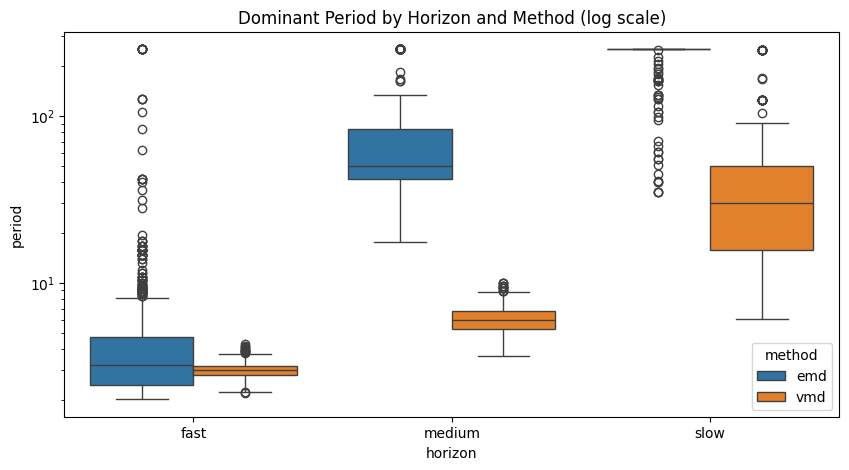

In [4]:
def to_long(df, method):
    rows = []
    for horizon in ["fast", "medium", "slow"]:
        rows.append(pd.DataFrame({
            "period": df[f"{horizon}_{method}_period"],
            "zc": df[f"{horizon}_{method}_zc"],
            "acf": df[f"{horizon}_{method}_acf"],
            "horizon": horizon,
            "method": method
        }))
    return pd.concat(rows)

emd_long = to_long(results, "emd")
vmd_long = to_long(results, "vmd")

long_df = pd.concat([emd_long, vmd_long]).reset_index(drop=True)

plt.figure(figsize=(10,5))
sns.boxplot(data=long_df, x="horizon", y="period", hue="method")
plt.yscale("log")
plt.title("Dominant Period by Horizon and Method (log scale)")
plt.show()

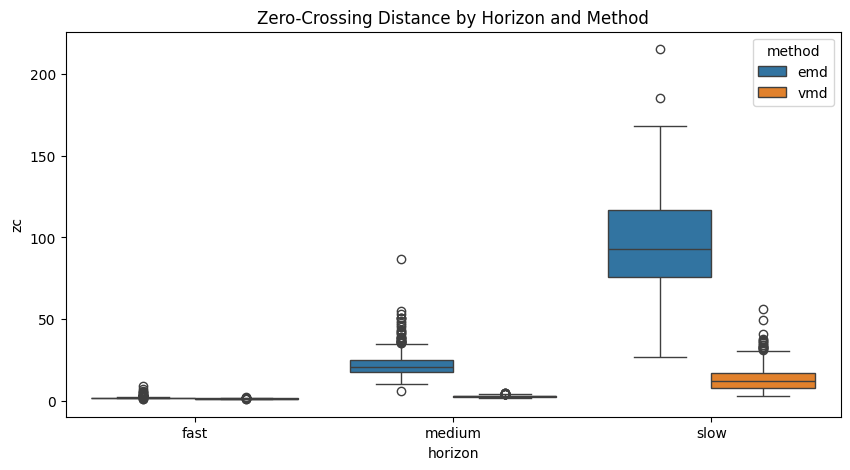

In [5]:
plt.figure(figsize=(10,5))
sns.boxplot(data=long_df, x="horizon", y="zc", hue="method")
plt.title("Zero-Crossing Distance by Horizon and Method")
plt.show()

## Interpretation of Dominant Period and Zero-Crossing Results

### Dominant Period (Frequency-Domain Evidence)

The first figure reports the distribution of dominant periods—estimated via Welch spectral density—for the fast, medium, and slow components obtained from EMD and VMD (\(K = 3\)). Periods are displayed on a logarithmic scale to highlight differences across time horizons.

For **EMD**, the results exhibit a clear and monotonic separation across horizons:

- The **fast EMD mode** concentrates around very short periods (approximately 2–5 trading days), consistent with high-frequency market fluctuations.
- The **medium EMD mode** shifts by more than one order of magnitude, clustering around 40–70 days, corresponding to intermediate-term market cycles.
- The **slow EMD mode** exhibits dominant periods close to the full sample length (approximately 250 days), indicating long-term, trend-like behavior.

This pronounced scale separation demonstrates that EMD endogenously decomposes returns into economically meaningful horizons without imposing predefined frequency bands.

In contrast, **VMD with \(K = 3\)** shows a much weaker separation:

- All three VMD modes remain within a relatively narrow range of dominant periods.
- Even the slow VMD mode typically oscillates at horizons of only several tens of days, rather than approaching the full-sample scale.
- The fast VMD mode is substantially slower than the fast EMD mode, indicating leakage of medium-frequency dynamics into the high-frequency component.

These patterns suggest that VMD with a small, fixed number of modes behaves more like a coarse frequency filter bank than a true multi-horizon decomposition.

---

### Zero-Crossing Distance (Time-Domain Evidence)

The second figure reports the distribution of mean zero-crossing distances, which measure the average time between sign changes and thus provide a time-domain proxy for oscillation speed and persistence.

For **EMD**, zero-crossing distances increase sharply across horizons:

- The **fast mode** shows very frequent sign changes (around 2 days), characteristic of noise and short-term trading dynamics.
- The **medium mode** exhibits substantially larger zero-crossing distances (approximately 15–30 days), reflecting smoother cyclical behavior.
- The **slow mode** displays extremely large zero-crossing distances—often exceeding 80–100 days—and in many assets no zero crossings occur at all, consistent with persistent trends rather than oscillatory motion.

This confirms that EMD modes are ordered not only in the frequency domain but also in the time domain by oscillation persistence.

For **VMD**, the increase in zero-crossing distance across horizons is much more modest:

- Even the slow VMD mode crosses zero frequently.
- None of the VMD modes exhibit trend-like behavior comparable to the slow EMD component.
- Considerable overlap across horizons remains, indicating limited temporal separation.

---

### Overall Interpretation

Taken together, the frequency-domain (dominant period) and time-domain (zero-crossing distance) analyses provide consistent evidence that:

- **EMD produces a genuine multi-horizon decomposition**, in which fast, medium, and slow components correspond to distinct market timescales with increasing persistence.
- **VMD with \(K = 3\) fails to recover long-term market trends**, instead yielding oscillatory components operating at relatively similar time scales.

These results justify interpreting EMD components as economically meaningful short-term fluctuations, medium-term cycles, and long-term trends, while suggesting caution when using low-dimensional VMD decompositions for horizon-based financial analysis.